In [93]:
%reset -f

In [94]:
import sys
sys.path.append(r"C:\ThesisWork\offical_approach\mth_project\mth_project\industrial_network_analysis")
from data_preprocessing import Dataset
from data_utils import remove_outliers

import warnings
import logging

warnings_logger = logging.getLogger('warnings')
warnings_logger.setLevel(logging.WARNING)
warning_handler = logging.FileHandler('warnings.log')
warning_handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
warnings_logger.addHandler(warning_handler)

def warning_handler_func(message, category, filename, lineno, file=None, line=None):
    warnings_logger.warning(f"{category.__name__}: {message} (File: {filename}, Line: {lineno})")

warnings.showwarning = warning_handler_func

In [95]:
### READ DATA
device_name = "A1-SW-B-246"
df = Dataset(f'C:\\ThesisWork\\offical_approach\\mth_project\\mth_project\\industrial_network_analysis\\Data082025\\{device_name}.csv')


In [96]:
### search criteria

# names for STATUSES
statuses = ': operational status'
statuses_exclude = 'Unused'

# names for OTHER NUMERIC PARAMETERS
icmp_params = 'ICMP'
temperature = 'temperature'
cpu = 'cpu'

numeric_exclude = "status"

# names for traffic on ports - BITS SENT/RECEIVED
bits = "bits"
bits_exclude = "unused"

In [97]:
all_names = df.get_column_names(name="bits")

In [109]:
def get_column_names_exclude(df, search_keyword, exclude_keyword):
    df_column_names = df.get_column_names(search_keyword)
    df_column_names_excluded = []

    for col in df_column_names:
        if exclude_keyword.lower() not in col.lower():
            df_column_names_excluded.append(col)

    return df_column_names_excluded

# df_column_names = get_column_names_exclude(df, icmp_params, numeric_exclude)\
#     + get_column_names_exclude(df, temperature, numeric_exclude)\
#     + get_column_names_exclude(df, cpu, numeric_exclude)

df_column_names = df.get_column_names("Interface Gi1/1(Valmet DNA Chain connection): Bits received")
df_column_names += df.get_column_names("Interface Gi1/1(Valmet DNA Chain connection): Bits sent")
df_column_names += df.get_column_names("Interface Gi1/2(Valmet DNA Chain connection): Bits received")
df_column_names += df.get_column_names("Interface Gi1/2(Valmet DNA Chain connection): Bits sent")
df_column_names += df.get_column_names("Interface Gi1/3(Valmet DNA access): Bits received")
df_column_names += df.get_column_names("Interface Gi1/3(Valmet DNA access): Bits sent")
#df_column_names += df.get_column_names("Interface Gi1/4(Valmet DNA access): Bits received")
#df_column_names += df.get_column_names("Interface Gi1/4(Valmet DNA access): Bits sent")
#df_column_names += df.get_column_names("Interface Gi1/5(Valmet DNA access): Bits received")
#df_column_names += df.get_column_names("Interface Gi1/5(Valmet DNA access): Bits sent")


In [110]:
# get values of defines columns
df_for_report = df.get_column_values(df_column_names)
#df_for_report = df.get_column_values(df_columns_for_report)

In [111]:
# ## PREPROCESS DATA
# #df_removed_outliers = remove_outliers(df0, 3)
# df_removed_outliers = remove_outliers(df_for_report, 3)

# # df_drop_nan = df_removed_outliers.dropna(axis=1, how='all')
# df_drop_nan = df_removed_outliers.dropna()

# # remove constant columns and duplicate columns
# df_removed_constants = df_drop_nan.loc[:, df_drop_nan.nunique() > 1]
# df_removed_duplicates = df_removed_constants.loc[:, ~df_drop_nan.T.duplicated()] 

plot raw values of dynamic features

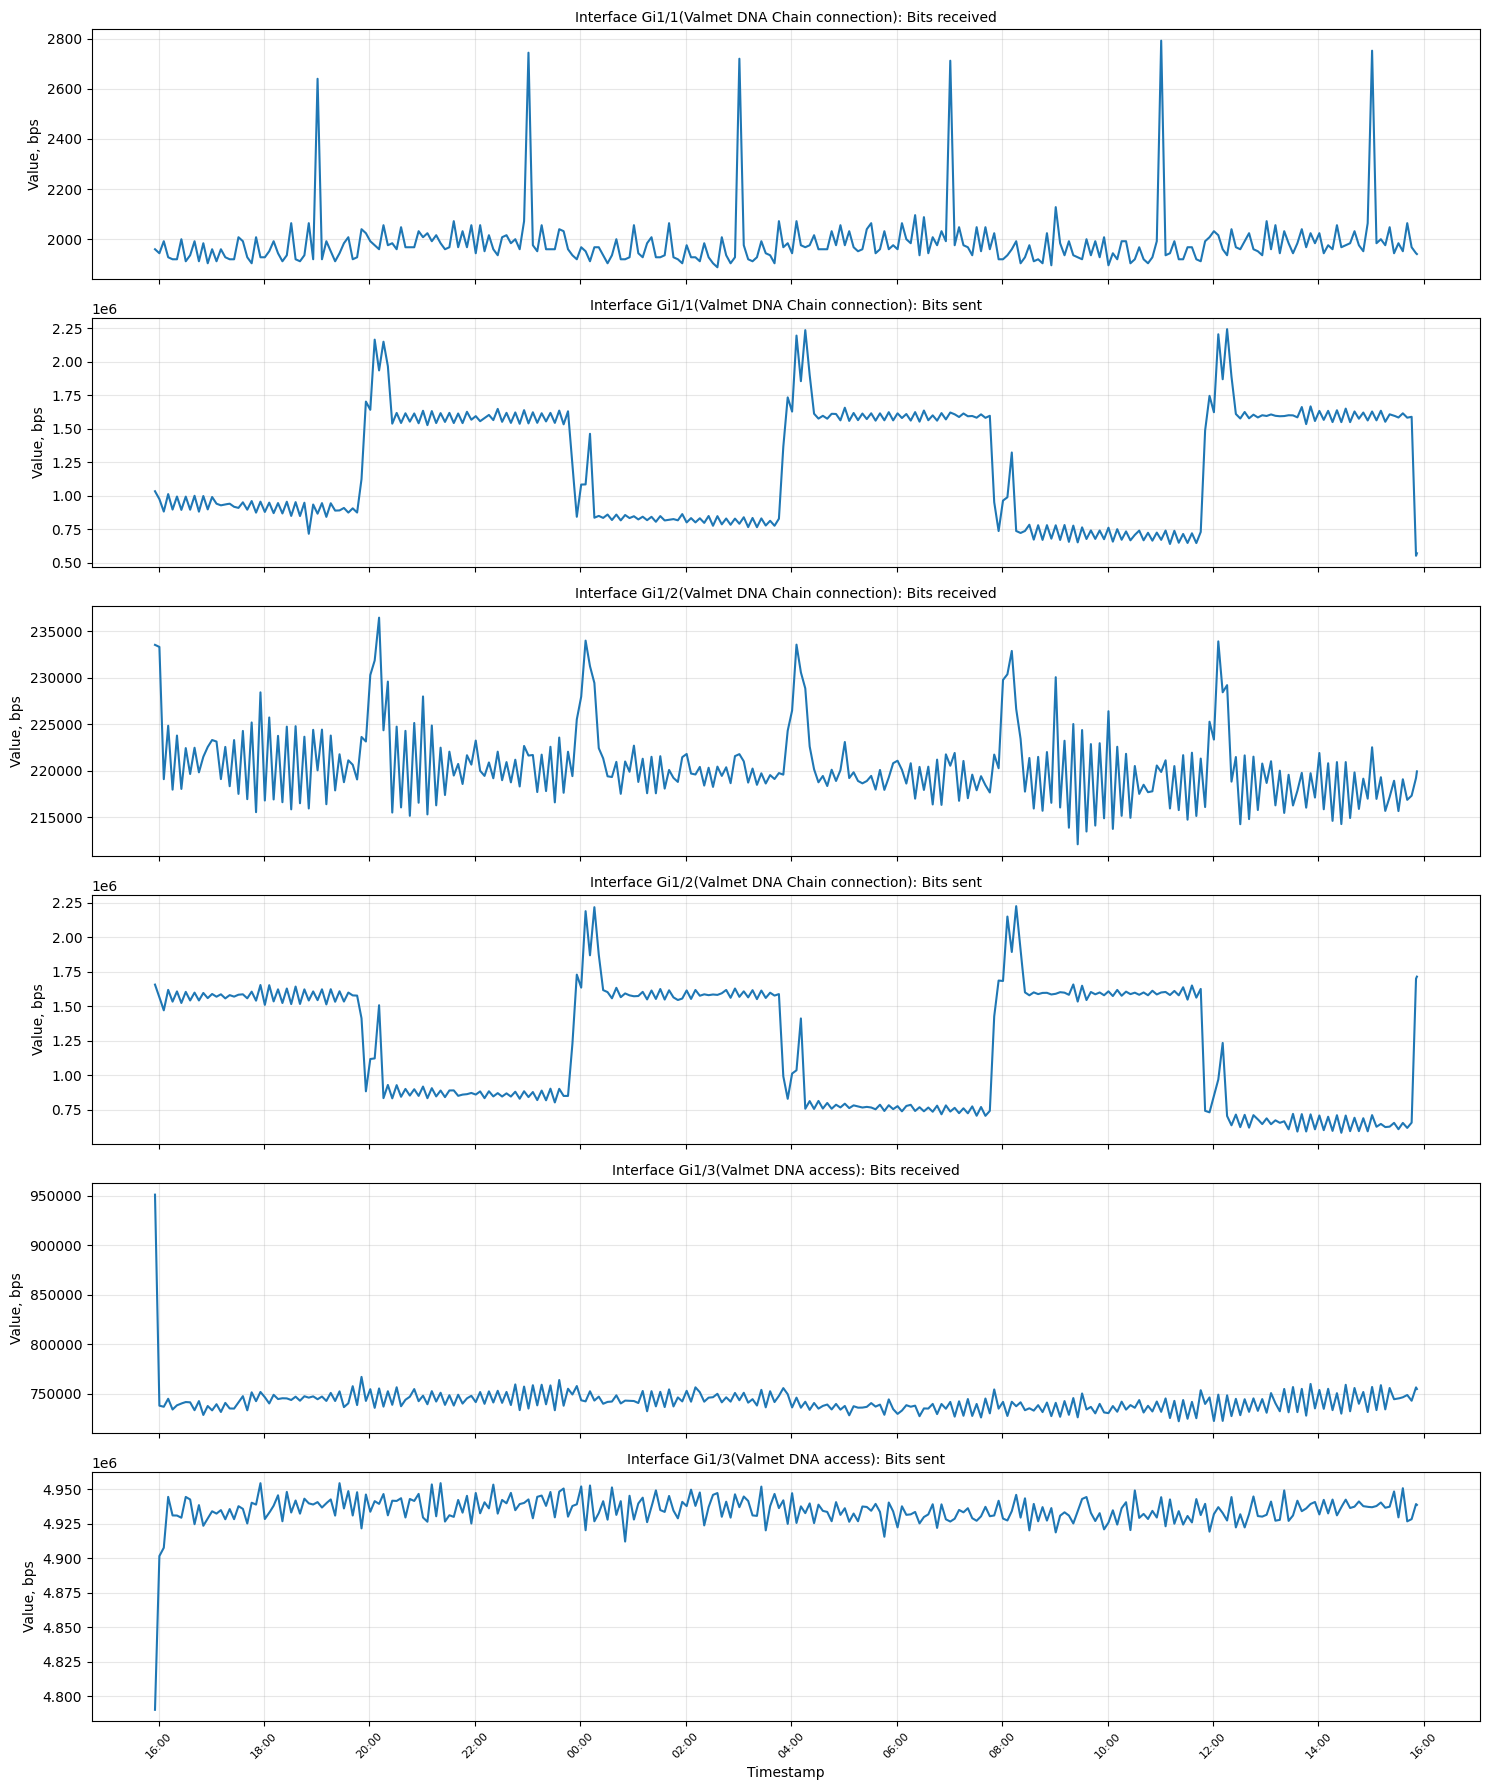

In [112]:
import matplotlib.pyplot as plt
import math
import matplotlib.dates as mdates
import pandas as pd


end_time = df_for_report.index[-1] - pd.Timedelta(days=4)
start_time = end_time - pd.Timedelta(days=0.04) # 1 hour
df_previous_day = df_for_report[:24*60]
#df_previous_day = df_for_report[start_time:end_time]
#df_previous_day = df_removed_duplicates
num_plots = len(df_previous_day.columns)
fig, axes = plt.subplots(num_plots, 1, figsize=(15, 3*num_plots), sharex=True)

# Handle case where there's only one column
if num_plots == 1:
    axes = [axes]

for i, col in enumerate(df_previous_day.columns):
    axes[i].plot(df_previous_day.index, df_previous_day[col])
    axes[i].set_ylabel('Value, bps')
    axes[i].set_title(col, fontsize=10)
    axes[i].grid(True, alpha=0.3)

# Only format x-axis on the bottom plot
axes[-1].set_xlabel('Timestamp')
axes[-1].tick_params(axis='x', rotation=45, labelsize=8)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=2))

plt.tight_layout()
plt.show()

In [113]:
from statsmodels.tsa.seasonal import seasonal_decompose

column = df_previous_day.columns[0]

result = seasonal_decompose(df_previous_day[column], model="additive", period=24)
result.plot()

ValueError: This function does not handle missing values

In [ ]:
# Compare only the trend components of multiple columns
columns_to_analyze = df_removed_duplicates.columns[5:11]

plt.figure(figsize=(15, 8))

for column in columns_to_analyze:
    result = seasonal_decompose(df_previous_day[column], model="additive", period=24)
    plt.plot(result.seasonal, label=f'{column} - Trend')

plt.title('Trend Components Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()